# Exact versus the textbook approximations

The familiar oscillation formulas -- the two-flavour $\sin^2(2\theta)\sin^2(\Delta m^2
L/4E)$, its constant-density counterpart with the matter-resonant mixing angle -- are not
approximations. Each is the **exact** solution of the problem it was derived for, and Mag$\nu$s
reproduces every one of them to machine precision. Showing that is the first half of this
notebook, and it is really a test of Mag$\nu$s rather than of the formulas.

What breaks is not the formula but the *problem substitution*: using a constant-density
formula for a profile that is not constant. The usual recipe -- take the mean density along
the path and plug it in -- is where the error enters, and on an Earth chord it is not a small
one. That is the second half.

The comparison uses `magnus.oscprobstd`, which ships the standard closed forms precisely so
that this kind of check is available without a second package.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.oscprobstd as oscprobstd
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.earth as earth
import magnus.globaldefs as gd
import magnus.plotting as plotting

# load_nufit_params returns exactly the six mixing parameters, ready to splat
# into any osc_prob_3nu_* call.  'NuFIT 6.1' is the package default.
OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
osc = OSC

## 1. The two-flavour vacuum formula is not an approximation

$$P(\nu_e \to \nu_\mu) = \sin^2 2\theta \,\sin^2\!\left(\frac{\Delta m^2 L}{4E}\right)$$

is exact for two flavours in vacuum, and the Magnus expansion has nothing to correct. Note
that `oscprobstd.osc_prob_2nu_vacuum_std` returns the full $2\times2$ probability **matrix**,
not a single number -- so it is indexed the same way as everything else in the package.

In [3]:
sth, Dm2 = osc['s12'], osc['D21']
E_gev = np.logspace(-1.0, 1.0, 400)
E = E_gev*gd.UNIT_GEV
L = 1300.0*gd.UNIT_KM

magnus_2nu = oscprob.osc_prob_2nu_vacuum(E, L, sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUMU)
closed_2nu = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth, Dm2, e, L)[gd.NUE][gd.NUMU]
                       for e in E])

print('2nu, vacuum       : max |Magnus - closed form| = %.2e'
      % np.max(np.abs(magnus_2nu - closed_2nu)))

2nu, vacuum       : max |Magnus - closed form| = 4.44e-16


## 2. Three flavours in vacuum: still exact

Three flavours in vacuum has a closed form too, built from the PMNS matrix and the two
mass-squared splittings. Same story.

In [4]:
U = hamiltonians.pmns_mixing_matrix(OSC['s12'], OSC['s23'], OSC['s13'], OSC['dCP'])

magnus_3nu = oscprob.osc_prob_3nu_vacuum(E, L, **OSC, nu_i=gd.NUMU, nu_f=gd.NUE)
closed_3nu = np.array([oscprobstd.osc_prob_3nu_vacuum_std(U, OSC['D21'], OSC['D31'], e, L)
                       [gd.NUMU][gd.NUE] for e in E])

print('3nu, vacuum       : max |Magnus - closed form| = %.2e'
      % np.max(np.abs(magnus_3nu - closed_3nu)))

3nu, vacuum       : max |Magnus - closed form| = 4.84e-14


## 3. Constant density: exact when the density really is constant

The matter formula replaces the vacuum mixing angle and splitting with their in-matter
counterparts. It is exact for a genuinely constant potential, and again there is nothing to
correct.

In [5]:
RHO = 2.848                                    # Earth's crust [g cm^-3]
vcc = matter.vcc_func_from_rho_func(RHO, density_matter_is_in_g_per_cm3=True)

magnus_matter = oscprob.osc_prob_2nu_matter_constant_density(
    E, L, RHO, sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUMU,
    density_matter_is_in_g_per_cm3=True)
closed_matter = np.array([oscprobstd.osc_prob_2nu_matter_std(sth, Dm2, vcc, e, L)
                          [gd.NUE][gd.NUMU] for e in E])

print('V_CC              = %.4e eV' % vcc)
print('2nu, constant rho : max |Magnus - closed form| = %.2e'
      % np.max(np.abs(magnus_matter - closed_matter)))

V_CC              = 1.0781e-13 eV
2nu, constant rho : max |Magnus - closed form| = 3.33e-16


Three formulas, three agreements at the $10^{-14}$ level or better. Wherever a closed
form exists, Mag$\nu$s returns it.

## 4. Where it does break: a constant density standing in for a varying one

Now the substitution that is actually made in practice. A neutrino crossing the Earth through
the core passes from crust to mantle to outer and inner core and back -- from about 1 to 13
g cm$^{-3}$. The constant-density formula is still exact for *its* problem; it is just no
longer this problem.

We use the atmospheric sector ($\theta_{23}$, $\Delta m^2_{31}$), which is what an Earth chord
of this length actually probes.

In [6]:
sth_atm, Dm2_atm = osc['s23'], osc['D31']

def num_density_e_prem(r):
    return matter.num_density_e_func(r, earth.density_matter_func_prem,
                                     electron_fraction=0.5,
                                     density_matter_is_in_g_per_cm3=True)   # [eV^3]

def VCC_prem(r):
    return matter.VCC_func(r, num_density_e_prem)                            # [eV]

H_vac_atm = np.asarray(
    hamiltonians.hamiltonian_2nu_vacuum_energy_independent(sth_atm, Dm2_atm))

costhz = -1.0                                  # straight up through the core
L_km = earth.distance_traveled_inside_earth(costhz)
L_earth = L_km*gd.CONV_KM_TO_INV_EV

def H_prem(l, energy):
    r = earth.earth_radial_distance_from_depth(costhz, l/gd.CONV_KM_TO_INV_EV)
    return H_vac_atm/energy + hamiltonians.hamiltonian_2nu_matter(VCC_prem(r))

# The PREM shell boundaries are density *jumps*.  Declaring them keeps a slab from
# straddling one, which no amount of refinement fixes -- see notebook 14.
breakpoints = np.asarray(
    earth.prem_layer_edges_along_chord(costhz))*gd.CONV_KM_TO_INV_EV

print('chord length      = %.1f km' % L_km)
print('PREM edges on it  = %d' % len(breakpoints))

chord length      = 12742.0 km
PREM edges on it  = 18


The mean density along the chord is what someone reaching for the constant-density
formula would plug in, so that is what we compare against.

In [7]:
l_grid = np.linspace(0.0, L_km, 4001)
rho_along = earth.density_matter_func_prem(
    earth.earth_radial_distance_from_depth(costhz, l_grid))
rho_bar = float(np.mean(rho_along))
VCC_bar = matter.vcc_func_from_rho_func(rho_bar, density_matter_is_in_g_per_cm3=True)

print('density along the chord: %.2f g/cm^3 (core) -> %.2f (crust)'
      % (rho_along.max(), rho_along.min()))
print('mean density           : %.4f g/cm^3' % rho_bar)

density along the chord: 13.09 g/cm^3 (core) -> 1.02 (crust)
mean density           : 8.5898 g/cm^3


The cell below raises a `MagnusConvergenceWarning`. It is worth reading rather than
hiding: it reports that some slab was wider than the sufficient condition for convergence of
the Magnus series, which is a statement about **slab width, not about the answer** -- measured
false about three quarters of the time. Here the answer is converged (declaring the
breakpoints and tightening the tolerance by four orders of magnitude moves it in the sixth
decimal). Notebooks 20 and 21 take this apart properly.

In [8]:
E_gev_earth = np.logspace(0.0, 2.0, 240)
E_earth = E_gev_earth*gd.UNIT_GEV

exact = np.array([oscprob.osc_prob(lambda l, e=e: H_prem(l, e), 0.0, L_earth,
                                   t_breakpoints=breakpoints)[gd.NUMU][gd.NUMU]
                  for e in E_earth])
const_rho = np.array([oscprobstd.osc_prob_2nu_matter_std(sth_atm, Dm2_atm, VCC_bar, e, L_earth)
                      [gd.NUMU][gd.NUMU] for e in E_earth])
vacuum = np.array([oscprobstd.osc_prob_2nu_vacuum_std(sth_atm, Dm2_atm, e, L_earth)
                   [gd.NUMU][gd.NUMU] for e in E_earth])

gap = np.abs(exact - const_rho)
print('max |exact - constant rho| = %.3f   at %.2f GeV'
      % (gap.max(), E_gev_earth[gap.argmax()]))
print('rms                        = %.3f' % np.sqrt(np.mean(gap**2)))
print('max |exact - vacuum|       = %.3f' % np.max(np.abs(exact - vacuum)))

/home/mbustamante/Research/magnus/src/magnus/magnus.py:1790: MagnusConvergenceWarning: at least one time slab is too wide for guaranteed convergence of the Magnus series (||Omega||_2 >= pi, over by up to a factor of ten). This is a statement about the slab width, not about the answer: it reports that a sufficient condition for convergence was not met somewhere, and the error may be anywhere from negligible to large. To act on it, use more (narrower) slabs -- request a smaller rtol/atol, or raise n_slabs; raising magnus_exp_order will not help in this regime. If the profile has a density jump or a kink, pass t_breakpoints there as well: a slab straddling one is not fixed by any number of slabs. Do NOT assume the adaptive refinement has already taken care of it -- measured on a sawtooth density with rtol=atol=1e-3 explicitly requested, the refinement ran and the answer was still 7.5e-03, seven times outside the tolerance asked for. Shown once per session.
  return evolution_operators_fro

max |exact - constant rho| = 0.512   at 2.38 GeV
rms                        = 0.230
max |exact - vacuum|       = 0.979


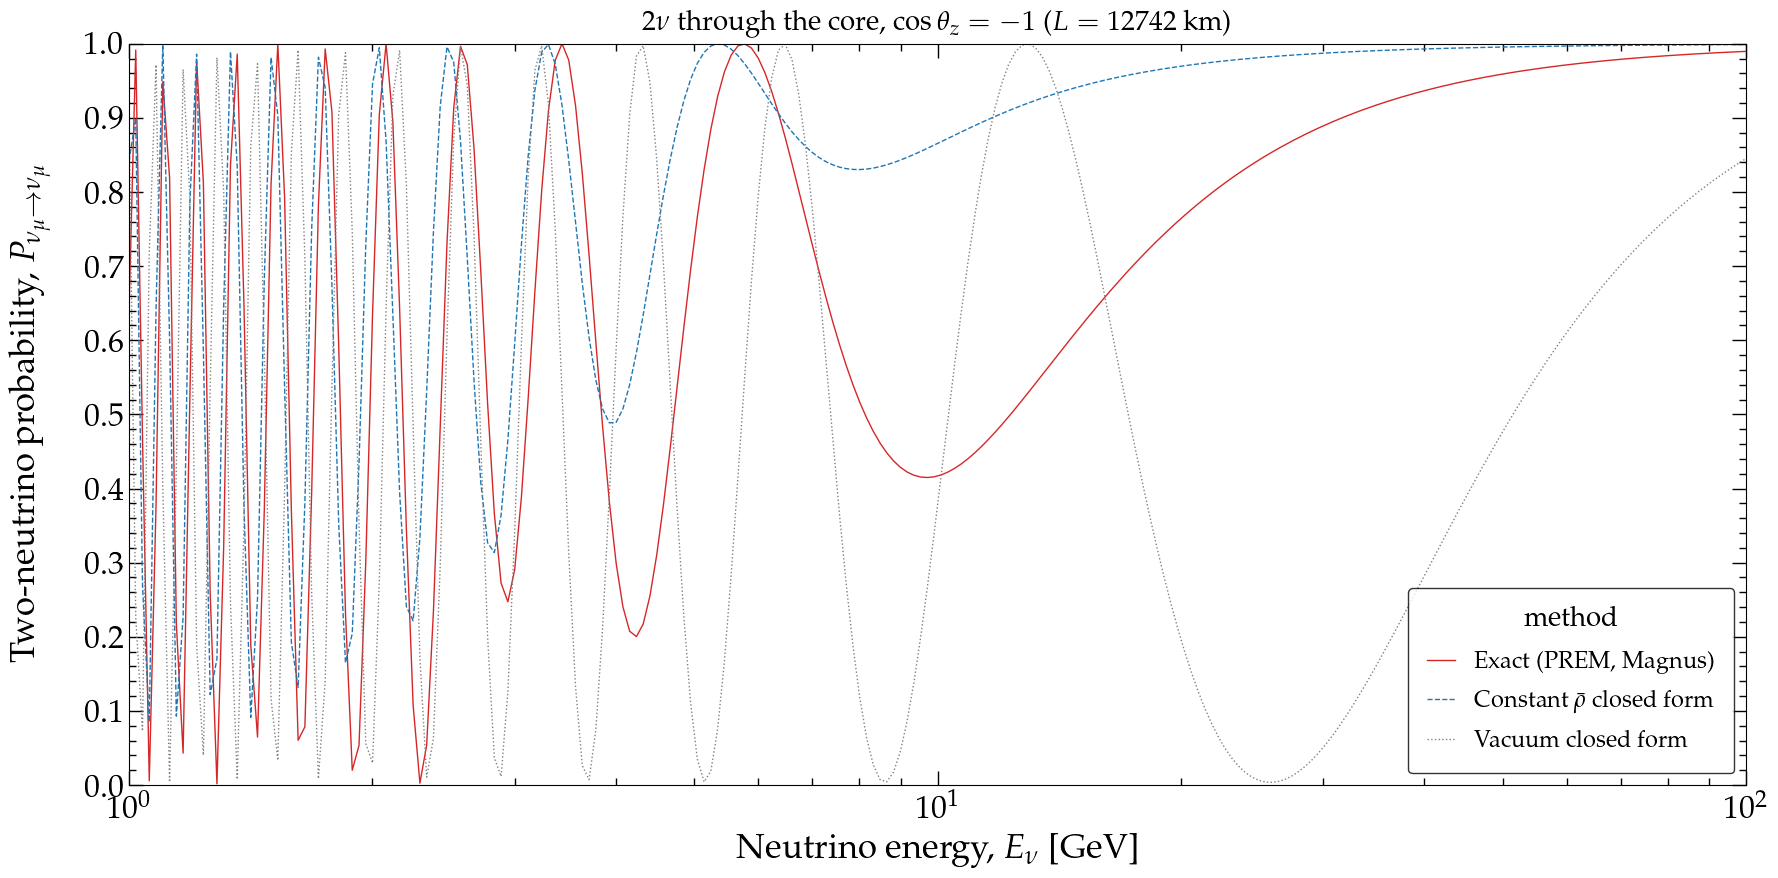

In [9]:
fig, ax = plotting.plot_probability_vs_energy(
    E_gev_earth,
    [dict(y=exact, label='Exact (PREM, Magnus)', color='C3'),
     dict(y=const_rho, label=r'Constant $\bar\rho$ closed form', color='C0', ls='--'),
     dict(y=vacuum, label='Vacuum closed form', color='0.5', ls=':')],
    nu_i=gd.NUMU, nu_f=gd.NUMU, num_flavors=2,
    xlim=(E_gev_earth[0], E_gev_earth[-1]),
    legend_title='method', legend_loc='lower right',
    title=(r'$2\nu$ through the core, $\cos\theta_z = -1$ '
           r'($L = %.0f$ km)' % L_km))

## Summary

| comparison | agreement |
|---|---|
| $2\nu$ vacuum, closed form | $4\times10^{-16}$ |
| $3\nu$ vacuum, closed form | $1\times10^{-14}$ |
| $2\nu$ constant density, closed form | $6\times10^{-16}$ |
| $2\nu$ Earth chord vs **mean-density** formula | **wrong by up to 0.51** |

The closed forms are exact and Mag$\nu$s agrees with all of them. The failure in the last row
is not the formula's -- it is the substitution of a constant density for a varying one, and it
is worth 0.51 in probability at the peak, with an rms of 0.23 across two decades in energy.

The mean density is not a bad *estimate* of the profile; it is simply not what the neutrino
sees. Oscillation depends on the arrangement of the matter along the path, not only on its
average -- which is the subject of notebook 18.

---

**Previous:** [Antineutrinos, done properly](15_magnus_antineutrinos.ipynb)  
**Next:** [Mass ordering and the octant](17_magnus_ordering_and_octant.ipynb) --- two open questions, and how large they actually are  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)